In [1]:
from google.colab import files
uploaded = files.upload()

Saving bangladesh_student_performance[1].csv to bangladesh_student_performance[1].csv


In [2]:
import pandas as pd
df = pd.read_csv('/content/bangladesh_student_performance[1].csv')

In [3]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
District,0
School_Type,0
Study_Hours_per_Week,0
Attendance,0
Parent_Education,0
Family_Income_BDT,0
Internet_Access,0


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
numerical_cols = ['Age', 'Study_Hours_per_Week', 'Attendance', 'Family_Income_BDT', 'Previous_GPA', 'SSC_Result', 'HSC_Result']
df_numerical = df[numerical_cols]

In [13]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numerical)

In [14]:
pca = PCA()
df_pca = pca.fit_transform(df_scaled)

In [15]:
explained_variance_ratio = pca.explained_variance_ratio_
display(pd.DataFrame({'Principal Component': range(1, len(explained_variance_ratio) + 1), 'Explained Variance Ratio': explained_variance_ratio}))

,Principal Component,Explained Variance Ratio
0,1,0.163874
1,2,0.150468
2,3,0.146538
3,4,0.140854
4,5,0.140052
5,6,0.130745
6,7,0.127469


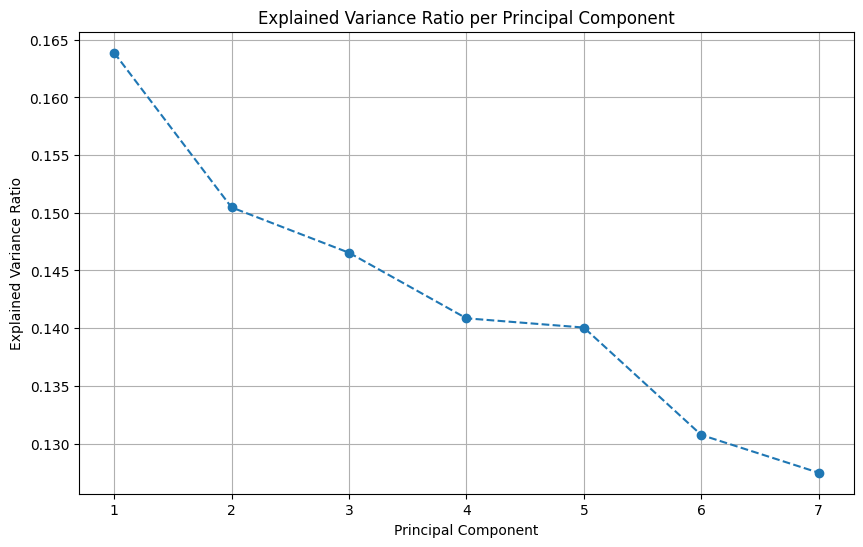

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Explained Variance Ratio per Principal Component')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [17]:
cumulative_explained_variance = explained_variance_ratio.cumsum()
display(pd.DataFrame({'Principal Component': range(1, len(cumulative_explained_variance) + 1), 'Cumulative Explained Variance': cumulative_explained_variance}))

,Principal Component,Cumulative Explained Variance
0,1,0.163874
1,2,0.314342
2,3,0.460881
3,4,0.601734
4,5,0.741786
5,6,0.872531
6,7,1.000000


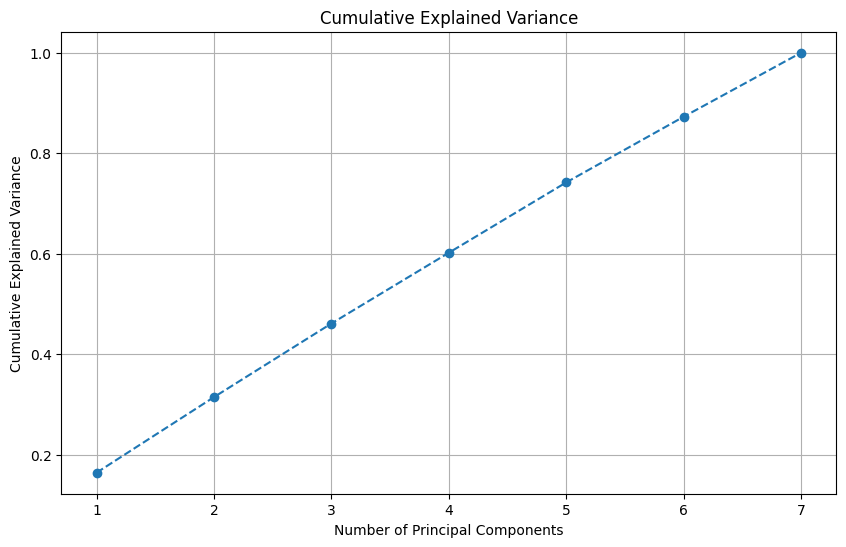

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()